In [1]:
import json
import glob
import statistics
import collections
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────
DETAIL_CSV  = r"eval_results_buas_First_Version\eval_detail_20260517_194026.csv"
SUMMARY_CSV = r"eval_results_buas_First_Version\eval_summary_20260517_194026.csv"
QUESTS_DIR  = r"eval_results_buas_First_Version"
# ───────────────────────────────────────────────────────────────────────────

COLORS = {"Qwen3.5-122B": "#378ADD", "GPT-OSS-120B": "#1D9E75"}

detail  = pd.read_csv(DETAIL_CSV)
summary = pd.read_csv(SUMMARY_CSV)
qwen_files = sorted(glob.glob(os.path.join(QUESTS_DIR, "quests_Qwen3*.json")))
gpt_files  = sorted(glob.glob(os.path.join(QUESTS_DIR, "quests_GPT*.json")))

print(f"Detail rows: {len(detail)}")
print(f"Summary rows: {len(summary)}")
print(f"Qwen quest files: {len(qwen_files)}")
print(f"GPT-OSS quest files: {len(gpt_files)}")
print(f"Models: {detail['model'].unique().tolist()}")

Detail rows: 60
Summary rows: 6
Qwen quest files: 10
GPT-OSS quest files: 10
Models: ['Qwen3.5-122B', 'GPT-OSS-120B']


# PART 1: QUANTITATIVE

In [3]:
numeric_cols = [c for c in detail.columns if c not in ('model', 'run', 'chapter_id')]

def model_stats(col):
    result = {}
    for m in models:
        vals = detail[detail['model'] == m][col].dropna().tolist()
        if vals:
            result[m] = {
                'mean': round(statistics.mean(vals), 3),
                'stdev': round(statistics.stdev(vals) if len(vals) > 1 else 0.0, 3)
            }
    return result

In [4]:
# Helper: mean and stdev per model for any metric
def model_stats(metric):
    results = {}
    for model in detail['model'].unique():
        vals = detail[detail['model'] == model][metric].tolist()
        results[model] = {
            'mean': round(statistics.mean(vals), 3),
            'stdev': round(statistics.stdev(vals), 3) if len(vals) > 1 else 0.0
        }
    return results

# Print summary for all numeric metrics
numeric_cols = [c for c in detail.columns if c not in ('model', 'run', 'chapter_id')]

print(f"{'Metric':<30} {'Qwen mean':>12} {'Qwen stdev':>12} {'GPT mean':>12} {'GPT stdev':>12}")
print("-" * 80)
for col in numeric_cols:
    s = model_stats(col)
    qw = s.get('Qwen3.5-122B', {})
    gp = s.get('GPT-OSS-120B', {})
    print(f"{col:<30} {qw.get('mean',''):>12} {qw.get('stdev',''):>12} {gp.get('mean',''):>12} {gp.get('stdev',''):>12}")

Metric                            Qwen mean   Qwen stdev     GPT mean    GPT stdev
--------------------------------------------------------------------------------
json_parse_success                        1          0.0            1          0.0
attempts                                  1          0.0            1          0.0
generation_time_s                    20.245        6.647       14.756        5.243
input_tokens                       8540.233        7.074       7874.8        5.863
output_tokens                        2508.2      844.669     2347.533      834.332
total_tokens                      11048.433      844.282    10222.333      834.358
num_quests                            3.667        1.093          1.6        0.932
num_steps                              23.6        7.938       17.367        8.648
scale_mismatch                        0.333        0.479        0.567        0.504
invalid_actions                           0          0.0            0          0.0
actor_

# BAR CHART: key metrics comparison

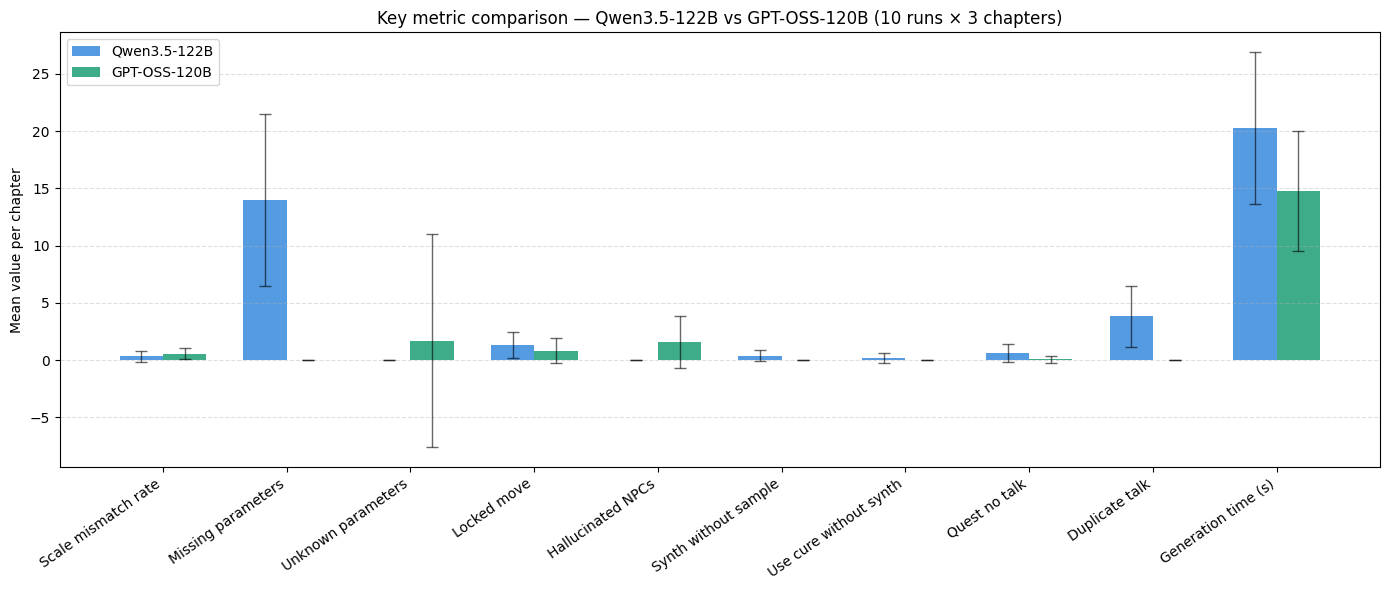

Saved → metric_comparison.png


In [5]:
metrics_to_plot = [
    ("scale_mismatch",        "Scale mismatch rate"),
    ("missing_parameters",    "Missing parameters"),
    ("unknown_parameters",    "Unknown parameters"),
    ("locked_move",           "Locked move"),
    ("hallucinated_npcs",     "Hallucinated NPCs"),
    ("synth_no_sample",       "Synth without sample"),
    ("use_cure_no_synth",     "Use cure without synth"),
    ("quest_no_talk",         "Quest no talk"),
    ("duplicate_talk",        "Duplicate talk"),
    ("generation_time_s",     "Generation time (s)"),
]

models = ["Qwen3.5-122B", "GPT-OSS-120B"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(models):
    means  = [model_stats(m)[model]['mean']  for m, _ in metrics_to_plot]
    stdevs = [model_stats(m)[model]['stdev'] for m, _ in metrics_to_plot]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width, label=model,
                  color=COLORS[model], alpha=0.85, yerr=stdevs,
                  capsize=4, error_kw={"elinewidth": 1, "alpha": 0.6})

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics_to_plot], rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Mean value per chapter")
ax.set_title("Key metric comparison — Qwen3.5-122B vs GPT-OSS-120B (10 runs × 3 chapters)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()
print("Saved → metric_comparison.png")

# PER-CHAPTER BREAKDOWN

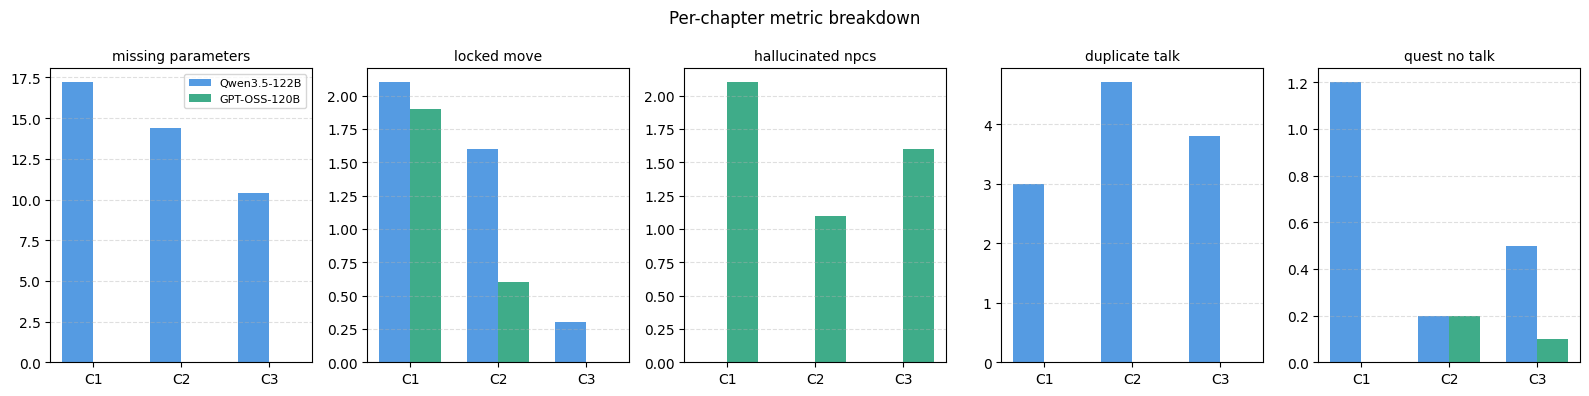

Saved → per_chapter_breakdown.png


In [6]:
chapter_metrics = ["missing_parameters", "locked_move", "hallucinated_npcs", "duplicate_talk", "quest_no_talk"]
chapters = ["C1", "C2", "C3"]
models = ["Qwen3.5-122B", "GPT-OSS-120B"]

fig, axes = plt.subplots(1, len(chapter_metrics), figsize=(16, 4), sharey=False)

for ax, metric in zip(axes, chapter_metrics):
    for i, model in enumerate(models):
        means = []
        for ch in chapters:
            vals = detail[(detail['model'] == model) & (detail['chapter_id'] == ch)][metric].tolist()
            means.append(round(statistics.mean(vals), 2))
        x = np.arange(len(chapters))
        ax.bar(x + i * 0.35, means, 0.35, label=model, color=COLORS[model], alpha=0.85)

    ax.set_title(metric.replace("_", " "), fontsize=10)
    ax.set_xticks(np.arange(len(chapters)) + 0.175)
    ax.set_xticklabels(chapters)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle("Per-chapter metric breakdown", fontsize=12)
plt.tight_layout()
plt.savefig("per_chapter_breakdown.png", dpi=150)
plt.show()
print("Saved → per_chapter_breakdown.png")

# MISSING PARAMETERS PER ACTION TYPE

In [7]:
def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

qwen_data = [entry for f in qwen_files for entry in load_json(f)]
gpt_data  = [entry for f in gpt_files  for entry in load_json(f)]

def load_action_library(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return {
        a["action"]: set(a.get("parameters", [])) - {"actor"}
        for a in raw.get("action_library", [])
    }

# Point this at your action_library.json
ACTION_LIBRARY_PATH = r"C:\Users\niels\OneDrive\Documents\2025-26-graduation-NielsWeissmann236814\Inputs\System\action_library.json"
req_params = load_action_library(ACTION_LIBRARY_PATH)

def count_missing_per_action(data):
    counter = collections.Counter()
    for entry in data:
        for quest in entry['quest_data'].get('quests', []):
            for step in quest.get('steps', []):
                action = step.get('action', '')
                params = step.get('parameters', {})
                expected = req_params.get(action, set()) - {'dialogue_content'}
                for ep in expected:
                    if ep not in params:
                        counter[action] += 1
    return counter

qwen_missing = count_missing_per_action(qwen_data)
gpt_missing  = count_missing_per_action(gpt_data)

all_actions = sorted(set(list(qwen_missing.keys()) + list(gpt_missing.keys())))

print(f"{'Action':<25} {'Qwen missing':>15} {'GPT-OSS missing':>15}")
print("-" * 57)
for action in all_actions:
    print(f"{action:<25} {qwen_missing.get(action, 0):>15} {gpt_missing.get(action, 0):>15}")

print()
print(f"Qwen total missing:    {sum(qwen_missing.values())}")
print(f"GPT-OSS total missing: {sum(gpt_missing.values())}")

Action                       Qwen missing GPT-OSS missing
---------------------------------------------------------
PICKUP                                110               0
SYNTHESIZE_CURE                         9               0
TALK                                  230               0
TURN_POWER_ON                          27               0
UNLOCK                                 34               0
USE_CURE                               10               0

Qwen total missing:    420
GPT-OSS total missing: 0


# MISSING PARAMETERS PER ACTION TYPE CHART

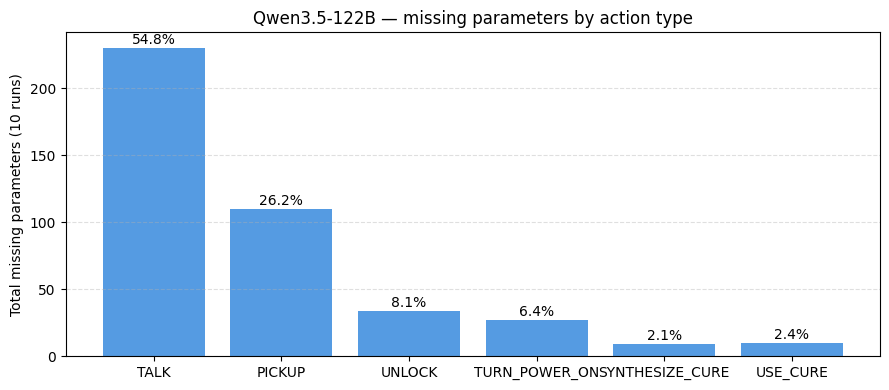

Saved → missing_params_by_action.png


In [8]:
actions = list(qwen_missing.keys())
qwen_counts = [qwen_missing[a] for a in actions]
total = sum(qwen_counts)
percentages = [round(c/total*100, 1) for c in qwen_counts]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(actions, qwen_counts, color="#378ADD", alpha=0.85)

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{pct}%", ha='center', fontsize=10)

ax.set_ylabel("Total missing parameters (10 runs)")
ax.set_title("Qwen3.5-122B — missing parameters by action type")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("missing_params_by_action.png", dpi=150)
plt.show()
print("Saved → missing_params_by_action.png")

# SAMPLE STEPS WITH MISSING PARAMETERS PER ACTION TYPE

In [9]:
def get_missing_samples(data, n=2):
    samples = collections.defaultdict(list)
    for entry in data:
        for quest in entry['quest_data'].get('quests', []):
            for step in quest.get('steps', []):
                action = step.get('action', '')
                params = step.get('parameters', {})
                expected = req_params.get(action, set()) - {'dialogue_content'}
                missing = [ep for ep in expected if ep not in params]
                if missing and len(samples[action]) < n:
                    samples[action].append({
                        'run':     entry['run'],
                        'chapter': entry['chapter_id'],
                        'missing': missing,
                        'step':    step
                    })
    return samples

samples = get_missing_samples(qwen_data, n=2)

for action, entries in sorted(samples.items()):
    print(f"=== {action} ===")
    for e in entries:
        print(f"  Run {e['run']} {e['chapter']} — missing fields: {e['missing']}")
        print(f"  Full step:")
        print(json.dumps(e['step'], indent=4))
        print()

=== PICKUP ===
  Run 1 C1 — missing fields: ['place', 'item']
  Full step:
{
    "step": 6,
    "action": "PICKUP",
    "actor": "player",
    "item": "lab_key_1",
    "place": "graveyard"
}

  Run 1 C1 — missing fields: ['place', 'item']
  Full step:
{
    "step": 10,
    "action": "PICKUP",
    "actor": "player",
    "item": "fuse_1",
    "place": "laboratory"
}

=== SYNTHESIZE_CURE ===
  Run 1 C1 — missing fields: ['place']
  Full step:
{
    "step": 23,
    "action": "SYNTHESIZE_CURE",
    "actor": "player",
    "place": "laboratory"
}

  Run 2 C1 — missing fields: ['place']
  Full step:
{
    "step": 19,
    "action": "SYNTHESIZE_CURE",
    "actor": "player",
    "place": "laboratory"
}

=== TALK ===
  Run 1 C1 — missing fields: ['target', 'place']
  Full step:
{
    "step": 3,
    "action": "TALK",
    "actor": "player",
    "target": "anne",
    "place": "store",
    "parameters": {
        "dialogue_content": [
            {
                "speaker": "PLAYER",
                

In [10]:
fake_zeros = 0
real_zeros = 0

for entry in qwen_data:
    for quest in entry['quest_data'].get('quests', []):
        for step in quest.get('steps', []):
            if step.get('action') == 'TALK':
                params_dc   = step.get('parameters', {}).get('dialogue_content', None)
                toplevel_dc = step.get('dialogue_content', None)
                
                if params_dc is not None and len(params_dc) == 0:
                    real_zeros += 1
                elif params_dc is None and toplevel_dc is not None and len(toplevel_dc) > 0:
                    fake_zeros += 1
                elif params_dc is None and (toplevel_dc is None or len(toplevel_dc) == 0):
                    real_zeros += 1

print(f"Fake zeros (dialogue exists at top level): {fake_zeros}")
print(f"Real zeros (dialogue genuinely absent):    {real_zeros}")

Fake zeros (dialogue exists at top level): 36
Real zeros (dialogue genuinely absent):    0


### Interpretation — missing parameters are formatting errors, not missing values

The output above shows the "missing" fields flagged by the eval script alongside the full raw JSON of each step.

In every single case, the flagged fields are visibly present in the step JSON, they are just placed at the top level of the step object instead of inside the `parameters` object.

For example, a PICKUP step is flagged as missing `item` and `place`, but the raw JSON shows:

```json
{
    "action": "PICKUP",
    "actor": "player",
    "item": "lab_key_1",
    "place": "graveyard"
}
```

The correct format according to the spec is:

```json
{
    "action": "PICKUP",
    "actor": "player",
    "parameters": {
        "item": "lab_key_1",
        "place": "graveyard"
    }
}
```

The model knows the correct values every time. It consistently places them one level too high in the JSON structure. This pattern holds across all 6 violating action types: TALK, PICKUP, UNLOCK, TURN_POWER_ON, USE_CURE, and SYNTHESIZE_CURE.

This is a JSON formatting compliance issue, not a knowledge or reasoning failure. A simple fix to the output format example in the prompt should resolve it entirely.

# Part 2 Qualitative 

In [11]:
def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def get_talk_steps(data):
    talks = []
    for entry in data:
        for quest in entry['quest_data'].get('quests', []):
            for step in quest.get('steps', []):
                if step.get('action') == 'TALK':
                    p = step.get('parameters', {})
                    target = (p.get('target') or step.get('target', '')).lower().strip()
                    dialogue = p.get('dialogue_content', [])
                    talks.append({
                        'run':       entry['run'],
                        'chapter':   entry['chapter_id'],
                        'target':    target,
                        'n_lines':   len(dialogue),
                        'lines':     dialogue,
                    })
    return talks

def get_titles(data):
    chapter_titles = [e['quest_data'].get('chapter_title', '') for e in data]
    quest_titles   = [q.get('quest_title', '')
                      for e in data
                      for q in e['quest_data'].get('quests', [])]
    return chapter_titles, quest_titles

# Load all quest data
qwen_data = [entry for f in qwen_files for entry in load_json(f)]
gpt_data  = [entry for f in gpt_files  for entry in load_json(f)]

for model_name, data in [("Qwen3.5-122B", qwen_data), ("GPT-OSS-120B", gpt_data)]:
    talks = get_talk_steps(data)
    chapter_titles, quest_titles = get_titles(data)

    npc_counter   = collections.Counter(t['target'] for t in talks if t['target'])
    line_lengths  = [t['n_lines'] for t in talks]
    unique_ct     = len(set(chapter_titles))
    unique_qt     = len(set(quest_titles))

    print(f"=== {model_name} ===")
    print(f"  Total TALK steps:        {len(talks)}")
    print(f"  Total dialogue lines:    {sum(line_lengths)}")
    print(f"  Avg lines per TALK:      {statistics.mean(line_lengths):.2f}  "
          f"min={min(line_lengths)}  max={max(line_lengths)}")
    print(f"  Unique chapter titles:   {unique_ct} / {len(chapter_titles)}")
    print(f"  Unique quest titles:     {unique_qt} / {len(quest_titles)}")
    print(f"  NPC usage: {dict(npc_counter.most_common())}")
    print()

=== Qwen3.5-122B ===
  Total TALK steps:        135
  Total dialogue lines:    454
  Avg lines per TALK:      3.36  min=0  max=8
  Unique chapter titles:   10 / 30
  Unique quest titles:     83 / 110
  NPC usage: {'sarah': 34, 'mary': 23, 'anne': 22, 'george': 21, 'the_doctor': 18, 'viktor': 10, 'marcus': 4, 'linda': 3}

=== GPT-OSS-120B ===
  Total TALK steps:        96
  Total dialogue lines:    272
  Avg lines per TALK:      2.83  min=2  max=6
  Unique chapter titles:   12 / 30
  Unique quest titles:     43 / 48
  NPC usage: {'sarah': 21, 'viktor': 21, 'anne': 20, 'mary': 15, 'the_doctor': 9, 'george': 4, 'the doctor': 3, 'marcus': 2, 'linda': 1}



# NPC USAGE CHART

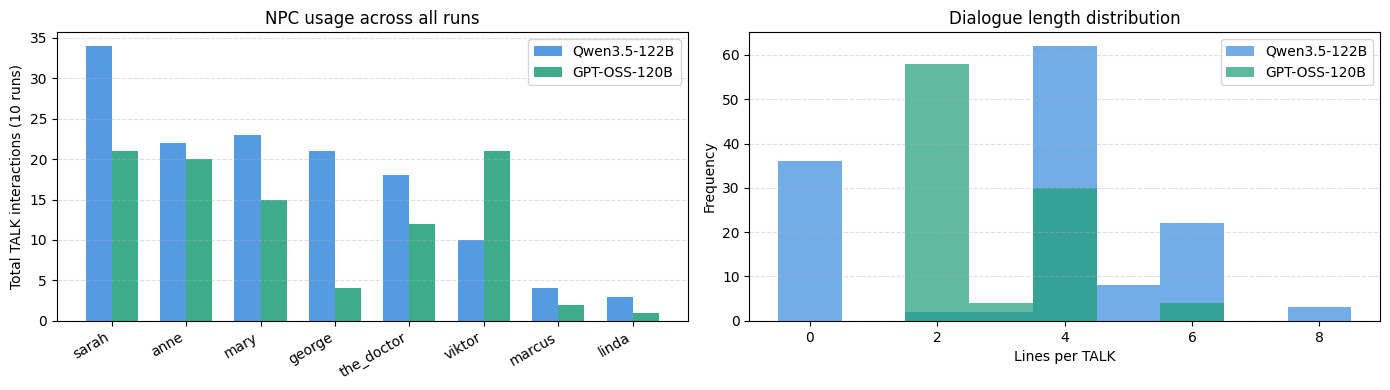

Saved → qualitative_npc_dialogue.png


In [12]:
all_npcs = ['sarah', 'anne', 'mary', 'george', 'the_doctor', 'viktor', 'marcus', 'linda']

qwen_talks = get_talk_steps(qwen_data)
gpt_talks  = get_talk_steps(gpt_data)

# Normalise "the doctor" → "the_doctor"
def normalise_target(t):
    return t.replace(' ', '_')

qwen_npc = collections.Counter(normalise_target(t['target']) for t in qwen_talks if t['target'])
gpt_npc  = collections.Counter(normalise_target(t['target']) for t in gpt_talks  if t['target'])

qwen_counts = [qwen_npc.get(npc, 0) for npc in all_npcs]
gpt_counts  = [gpt_npc.get(npc, 0)  for npc in all_npcs]

x = np.arange(len(all_npcs))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# NPC usage bar chart
ax = axes[0]
ax.bar(x - 0.175, qwen_counts, 0.35, label="Qwen3.5-122B", color="#378ADD", alpha=0.85)
ax.bar(x + 0.175, gpt_counts,  0.35, label="GPT-OSS-120B",  color="#1D9E75", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_npcs, rotation=30, ha='right')
ax.set_ylabel("Total TALK interactions (10 runs)")
ax.set_title("NPC usage across all runs")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Dialogue lines per TALK — histogram
ax = axes[1]
qwen_lengths = [t['n_lines'] for t in qwen_talks]
gpt_lengths  = [t['n_lines'] for t in gpt_talks]
bins = range(0, 10)
ax.hist(qwen_lengths, bins=bins, alpha=0.7, color="#378ADD", label="Qwen3.5-122B", align='left')
ax.hist(gpt_lengths,  bins=bins, alpha=0.7, color="#1D9E75", label="GPT-OSS-120B",  align='left')
ax.set_xlabel("Lines per TALK")
ax.set_ylabel("Frequency")
ax.set_title("Dialogue length distribution")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("qualitative_npc_dialogue.png", dpi=150)
plt.show()
print("Saved → qualitative_npc_dialogue.png")

### Note on the 0 values in Qwen's dialogue length distribution

The bar at 0 for Qwen in the histogram above does not mean those TALK steps have no dialogue. It means the dialogue_content field is placed at the top level of the step object instead of inside the parameters object, so the counter looks inside parameters, finds nothing, and records 0 lines.

This is confirmed by splitting all 0-line TALK steps into fake zeros and real zeros:

- Fake zeros (dialogue exists at top level): 36
- Real zeros (dialogue genuinely absent): 0

Every single empty dialogue case is a formatting error. Qwen always writes the dialogue, it just consistently places it at the wrong level in the JSON structure. There are zero cases of genuinely missing dialogue content.

# TITLE VARIETY PER CHAPTER

In [13]:
for model_name, data in [("Qwen3.5-122B", qwen_data), ("GPT-OSS-120B", gpt_data)]:
    print(f"=== {model_name} ===")
    for ch in ["C1", "C2", "C3"]:
        titles = [e['quest_data'].get('chapter_title', '')
                  for e in data if e['chapter_id'] == ch]
        counter = collections.Counter(titles)
        unique  = len(counter)
        top3    = counter.most_common(3)
        print(f"  {ch} — {unique}/10 unique titles")
        for title, count in top3:
            print(f"    '{title}' × {count}")
    print()

=== Qwen3.5-122B ===
  C1 — 5/10 unique titles
    'The First Spark' × 3
    'The Spark in the Dark' × 2
    'The Spark and the Sample' × 2
  C2 — 3/10 unique titles
    'The Puppeteer's Shadow' × 6
    'The Puppet Master's Shadow' × 3
    'The Architect of Chaos' × 1
  C3 — 2/10 unique titles
    'The Last Departure' × 6
    'The Final Departure' × 4

=== GPT-OSS-120B ===
  C1 — 1/10 unique titles
    'A Flicker of Hope' × 10
  C2 — 4/10 unique titles
    'Strings of the Shadow' × 4
    'Strings of Control' × 3
    'Unmasking the Puppet Master' × 2
  C3 — 8/10 unique titles
    'The Final Escape' × 3
    'A Flicker of Hope' × 1
    'Escape the Isle' × 1



# QUALITATIVE SUMMARY TABLE

In [14]:
qwen_talks = get_talk_steps(qwen_data)
gpt_talks  = get_talk_steps(gpt_data)

qwen_ct, qwen_qt = get_titles(qwen_data)
gpt_ct,  gpt_qt  = get_titles(gpt_data)

qwen_empty_dialogue = sum(1 for t in qwen_talks if t['n_lines'] == 0)
gpt_empty_dialogue  = sum(1 for t in gpt_talks  if t['n_lines'] == 0)

rows = [
    ("Total TALK steps",              len(qwen_talks),                          len(gpt_talks)),
    ("Total dialogue lines",          sum(t['n_lines'] for t in qwen_talks),    sum(t['n_lines'] for t in gpt_talks)),
    ("Avg lines per TALK",            round(statistics.mean([t['n_lines'] for t in qwen_talks]), 2), round(statistics.mean([t['n_lines'] for t in gpt_talks]), 2)),
    ("Max lines in one TALK",         max(t['n_lines'] for t in qwen_talks),    max(t['n_lines'] for t in gpt_talks)),
    ("Unique chapter titles (of 30)", len(set(qwen_ct)),                        len(set(gpt_ct))),
    ("Unique quest titles",           len(set(qwen_qt)),                        len(set(gpt_qt))),
    ("Total quest titles",            len(qwen_qt),                             len(gpt_qt)),
    ("NPCs used (of 8)",              len(set(normalise_target(t['target']) for t in qwen_talks if t['target'])),
                                      len(set(normalise_target(t['target']) for t in gpt_talks  if t['target']))),
    ("C1 unique chapter titles",      len(set(e['quest_data'].get('chapter_title','') for e in qwen_data if e['chapter_id']=='C1')),
                                      len(set(e['quest_data'].get('chapter_title','') for e in gpt_data  if e['chapter_id']=='C1'))),
]

print(f"{'Metric':<35} {'Qwen3.5-122B':>15} {'GPT-OSS-120B':>15}")
print("-" * 67)
for label, qval, gval in rows:
    print(f"{label:<35} {str(qval):>15} {str(gval):>15}")

Metric                                 Qwen3.5-122B    GPT-OSS-120B
-------------------------------------------------------------------
Total TALK steps                                135              96
Total dialogue lines                            454             272
Avg lines per TALK                             3.36            2.83
Max lines in one TALK                             8               6
Unique chapter titles (of 30)                    10              12
Unique quest titles                              83              43
Total quest titles                              110              48
NPCs used (of 8)                                  8               8
C1 unique chapter titles                          5               1


---

## Findings Summary

### Quantitative

#### Structural validity
Measures whether the output conforms to the expected format and scale.

- json_parse_success: 100% for both models. Zero retries needed across all 30 runs each.
- num_quests: Qwen averages 3.7 quests per chapter. GPT-OSS averages 1.6. Qwen splits work into more sub-quests.
- num_steps: Qwen averages 23.6 steps per chapter (±7.9). GPT-OSS averages 17.4 (±8.6). Both have high variance.
- scale_mismatch: Qwen 33%. GPT-OSS 57%. GPT-OSS misses the target scale nearly twice as often.

#### Action validity
Measures whether actions are legal and correctly formed.

- invalid_actions: 0 for both. Neither model ever invented an action outside the action library.
- actor_not_player: 0 for both. Every step was correctly assigned to the player.
- missing_parameters: Qwen 14.0 per chapter (±7.5). GPT-OSS 0. Qwen places required action fields at the top level of the step object instead of inside the parameters object in every single run. Verified by inspecting raw step JSON across all action types. The values are always present and correct, just structurally misplaced. This is a JSON formatting compliance issue, not a knowledge or reasoning failure.
- unknown_parameters: Qwen 0. GPT-OSS 1.7 per chapter (±9.3). Rare for GPT-OSS but severe when it occurs.

#### World state consistency
Measures whether steps respect the current state of the world.

- locked_move: Qwen 1.33 per chapter (±1.1). GPT-OSS 0.83 (±1.1). Both walk into locked locations without unlocking first. Qwen more often.
- move_noop: Qwen 0.17. GPT-OSS 0.23. Both near-zero. Occasionally plans a MOVE from a location to itself.
- hallucinated_locations: 0 for both. Neither model ever referenced a location not in the world state.
- hallucinated_npcs: Qwen 0. GPT-OSS 1.6 per chapter (±2.3). GPT-OSS regularly invents character names. Qwen never does this.
- hallucinated_items: Qwen 0.03. GPT-OSS 0. Both near-zero. Qwen had one item hallucination across 30 runs.

#### Inventory consistency
Measures whether the model correctly tracks what the player is carrying.

- pickup_no_move: Qwen 0.07. GPT-OSS 0.03. Both near-zero. Occasionally picks up an item without moving there first.
- synth_no_sample: Qwen 0.40. GPT-OSS 0. Qwen sometimes synthesizes the cure without having collected the sample first.
- repair_no_toolkit: Qwen 0.03. GPT-OSS 0.07. Both very low.
- repair_no_wood: Qwen 0.20. GPT-OSS 0. Qwen occasionally attempts repairs without the required wood.
- use_cure_no_synth: Qwen 0.20. GPT-OSS 0. Qwen occasionally uses the antidote before synthesizing it.

#### Narrative coherence
Measures whether the quest makes sense as a story.

- quest_no_talk: Qwen 0.63 per chapter. GPT-OSS 0.10. Qwen frequently generates quests with zero NPC interaction.
- duplicate_talk: Qwen 3.83 per chapter (±2.7). GPT-OSS 0. Qwen repeatedly talks to the same NPC back-to-back in almost every run. GPT-OSS has zero violations.

#### Performance
Measures how efficiently the model produced the output.

- generation_time_s: Qwen 20.2s per chapter (±6.6). GPT-OSS 14.8s (±5.2). GPT-OSS is roughly 27% faster.
- input_tokens: Qwen 8,540 per chapter. GPT-OSS 7,875. Similar input size.
- output_tokens: Qwen 2,508 per chapter (±845). GPT-OSS 2,348 (±834). Qwen outputs slightly more due to longer chapters.
- total_tokens: Qwen 11,048 per chapter. GPT-OSS 10,222.
- attempts: 1.0 for both. Both always succeeded on the first attempt. Zero retries needed.

---

### Qualitative

#### Dialogue quality
- Total TALK steps: Qwen 135. GPT-OSS 96. Qwen produces significantly more dialogue interactions overall.
- Total dialogue lines: Qwen 454. GPT-OSS 272.
- Avg lines per TALK: Qwen 3.36. GPT-OSS 2.83. Qwen writes longer exchanges.
- Max lines in one TALK: Qwen 8. GPT-OSS 6. Qwen reaches the maximum allowed dialogue length; GPT-OSS does not.
- TALK steps with empty dialogue: Qwen has 36 TALK steps where dialogue_content appears to be empty. All 36 are confirmed fake zeros. The dialogue exists but is placed at the top level of the step object instead of inside parameters, so the counter records 0 lines. There are zero cases of genuinely missing dialogue. This is the same formatting issue as the missing parameters finding and would be resolved by the same prompt fix.
- Qwen produces richer, more character-driven dialogue. Characters have distinct voices and subtext. The Doctor is cold and clinical, Viktor is brutal and ideological, Anne is street-wise.
- GPT-OSS produces functional but thin dialogue. Short declarative lines that convey information without personality.

#### Variety across runs
- Unique chapter titles: Qwen 10 out of 30. GPT-OSS 12 out of 30.
- Unique quest titles: Qwen 83 out of 110. GPT-OSS 43 out of 48.
- C1 unique chapter titles: Qwen 5 out of 10. GPT-OSS 1 out of 10. GPT-OSS uses "A Flicker of Hope" in all 10 C1 runs.
- Qwen shows more genuine variation in wording and story framing. GPT-OSS is nearly deterministic in C1.

#### NPC coverage
- NPCs used out of 8: both models use all 8 characters at least once across 10 runs.
- Qwen distributes interactions more evenly: sarah (34), anne (22), mary (23), george (21), the_doctor (18), viktor (10), marcus (4), linda (3).
- GPT-OSS concentrates on a smaller core cast: sarah (21), viktor (21), anne (20), mary (15), the_doctor (9), george (4), marcus (2), linda (1).

#### Story coherence and creativity
- Qwen splits chapters into 3 to 7 sub-quests with more structural variety. Occasional creative deviations from the expected path.
- GPT-OSS tends toward 1 to 2 large quests per chapter. Tighter and more focused but narratively thin.
- Both produce coherent quest arcs. Qwen has more depth; GPT-OSS has less padding.

---

### Core finding

The two models have opposite and complementary failure profiles.

**Qwen3.5-122B** is the better storyteller. Richer dialogue, broader NPC usage, more variety, stronger character voices. Its apparent failures in rule compliance are less severe than the raw numbers suggest. The missing parameters metric (420 total violations, 14.0 per chapter) is entirely caused by a consistent JSON formatting habit where fields are placed at the wrong level in the step object. The values are always correct. This is fixable with a better output format example in the prompt or a post-processing normalisation step in the code. The remaining genuine issues are duplicate talks and inventory sequencing errors, both of which are prompt compliance problems rather than capability limits.

**GPT-OSS-120B** is the better executor. Zero missing parameters, zero duplicate talks, correct inventory sequencing, faster generation. Its failures are in world grounding and creative quality: hallucinated NPCs, repetitive structure, thin dialogue.

Neither model is a complete solution. An ideal quest generation system would combine Qwen's creative output with GPT-OSS's rule compliance. If Qwen's formatting issue is resolved through prompt or code improvements, it would become the stronger candidate overall given its superior storytelling quality.

### Important note

The conclusion that Qwen's missing parameters are fixable is based on the observation that the values are always present at the wrong JSON level. This has not yet been verified through a prompt improvement iteration. Whether these errors persist after prompt refinement is a key open question.

If the formatting errors are resolved through prompt or code improvements, Qwen becomes the stronger overall candidate given its superior storytelling quality. If they persist despite fixes, the errors are game-breaking in practice. A quest step with a missing item field, missing target field, or missing location field cannot be executed by the game engine regardless of how good the surrounding content is. In that scenario the opposite failure profiles conclusion holds and GPT-OSS becomes the more viable model despite its weaker creative output. A before/after evaluation after prompt improvements is therefore the most important next step.

---

### Future work

#### Validation improvements
- Add a minimum line count check to the dialogue validator. Any TALK step with fewer than 2 lines in dialogue_content should be treated as a validation failure and trigger a retry. This would catch the 36 TALK steps in Qwen that currently pass through with empty dialogue due to the formatting issue.
- Add a check that verifies parameters are inside the parameters object and not at the top level of the step. This would catch Qwen's missing parameters pattern where the data is present but placed at the wrong JSON level.
- Add a check that rejects any quest that has zero TALK steps entirely, rather than just counting it as a narrative coherence metric after the fact.



#### Prompt improvements
- Fix the JSON structure compliance issue causing Qwen's missing parameters. Since all 420 violations are confirmed formatting errors with correct values at the wrong level, a simple output format fix in the prompt showing fields explicitly nested inside the parameters object should resolve this entirely.
- Strengthen the duplicate talk instruction. The current wording is not prominent enough. Qwen violates it in almost every run despite it being in the prompt. Moving it higher or rephrasing it as a hard constraint may reduce violations.
- Add explicit pre-planning instructions for locked locations. Telling the model to list all location conditions before planning any MOVE step would reduce locked_move errors.
- Add explicit inventory sequencing rules. A numbered prerequisite chain (pick up sample before synthesizing, synthesize before using cure) stated clearly in the prompt would likely fix Qwen's inventory sequencing errors.
- Improve the output format example to show parameters placed correctly inside the parameters object, with a negative example showing what not to do.

#### Evaluation improvements
- Add a third model once server availability allows. Two models is sufficient for initial findings but a third would strengthen the comparison and allow pattern detection across architectures.
- Run a before/after evaluation after prompt improvements to measure whether the changes actually reduce errors. This would turn the evaluation into an iterative improvement loop rather than a one-time measurement.